## Trabajo en clase 05: Cuadratura Gaussiana e integración en intervalos Infinitos

**Nombre completo:Efrain Rojas García**

**Carné: C36883**

### Fecha de entrega
Jueves 24 de setiembre de 2026, 23:59 h.

### Instrucciones generales
Lea los enunciados de los siguientes dos ejercicios, **complete el código** faltante y **responda a las preguntas planteadas**.

### Formato de entrega
Guarde el notebook en una carpeta llamanda `05-Trabajo_en_clase` y subir a su repositorio privado en GitHub.


## Integración numérica en intervalos infinitos

Los métodos de integración numérica estudiados anteriormente están formulados
para intervalos finitos. Sin embargo, muchas integrales de interés en física
aparecen sobre intervalos infinitos.

El objetivo de este ejercicio es transformar dos integrales impropias a
intervalos finitos y estudiar posteriormente su aproximación mediante:

- trapecio compuesto,
- Simpson compuesto,
- cuadratura de Gaussiana.

Considere las integrales

$$
I_1=\int_0^\infty e^{-x}\,dx
$$

y

$$
I_2=\int_{-\infty}^{\infty}e^{-x^2}\,dx.
$$

Sus valores exactos son

$$
I_1=1,
\qquad
I_2=\sqrt{\pi}.
$$

Estos valores se utilizarán únicamente para evaluar el error de las
aproximaciones numéricas.

### 1. Transformación a intervalos finitos (15 puntos)

Antes de aplicar los métodos numéricos, transforme cada integral impropia a
un intervalo finito.

#### a. Integral semi-infinita

Para

$$
I_1=\int_0^\infty e^{-x}\,dx,
$$

utilice el cambio de variable

$$
x=\frac{t}{1-t},
\qquad
0\leq t<1.
$$

El diferencial está dado por

$$
dx=\frac{1}{(1-t)^2}\,dt.
$$

Sustituya estas expresiones en la integral y escriba el integrando
transformado completamente en términos de $t$.

---

#### b. Integral sobre toda la recta real

Para

$$
I_2=\int_{-\infty}^{\infty}e^{-x^2}\,dx,
$$

utilice

$$
x=\tan\left(\frac{\pi t}{2}\right),
\qquad
-1<t<1.
$$

En este caso,

$$
dx=
\frac{\pi}{2}
\sec^2\left(\frac{\pi t}{2}\right)\,dt.
$$

Sustituya estas expresiones y escriba la integral transformada completamente
en términos de $t$.

### 2. Implementación de las funciones transformadas (15 puntos)

Implemente en Python los integrandos obtenidos en la sección anterior.

Defina:

- `f1_transformada(t)`,
- `f2_transformada(t)`.

Aunque las expresiones algebraicas contienen factores que crecen cerca de
los extremos del intervalo, los integrandos completos satisfacen

$$
\lim_{t\to1^-}f_1(t)=0
$$

y

$$
\lim_{t\to\pm1}f_2(t)=0.
$$

Para evitar problemas numéricos al evaluar exactamente estos puntos, defina
explícitamente el valor límite como cero.

Las funciones deben aceptar tanto escalares como arreglos de NumPy.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import roots_legendre

def f1_transformada(t):
    t = np.asarray(t, dtype=float)

    # Inicializamos con el valor límite en t = 1
    resultado = np.zeros_like(t)

    # Evaluamos solamente donde t < 1
    mascara = t < 1.0

    resultado[mascara] = (np.exp(-t[mascara]/(1-t[mascara])))*(1/((1-t[mascara])**2))
    '''
        TODO: Completar 
    '''
   
                                
    # Permite que la función también devuelva un escalar
    if resultado.ndim == 0:
        return resultado.item()

    return resultado    

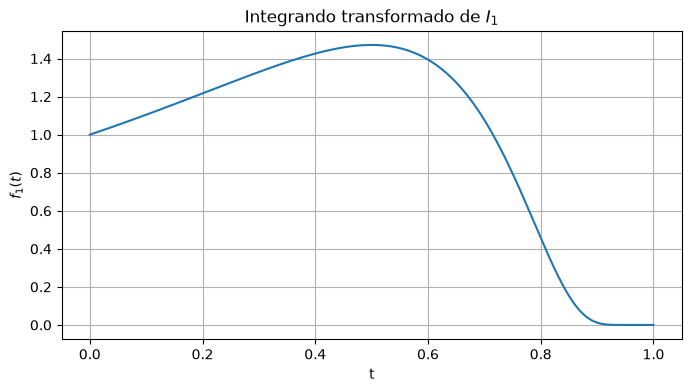

In [7]:
t1 = np.linspace(0, 1, 1000)
t2 = np.linspace(-1, 1, 1000)

plt.figure(figsize=(8, 4))
plt.plot(t1, f1_transformada(t1))
plt.xlabel('t')
plt.ylabel(r'$f_1(t)$')
plt.title('Integrando transformado de $I_1$')
plt.grid(True)
plt.show()

In [8]:
def f2_transformada(t):
    t = np.asarray(t, dtype=float)

    # Inicializamos con el valor límite en t = ±1
    resultado = np.zeros_like(t)

    # Evaluamos únicamente en el interior del intervalo
    mascara = np.abs(t) < 1.0

    u = 0.5 * np.pi * t[mascara]

    resultado[mascara] = (np.exp(-np.tan(u)**2))*((np.pi/2)*(1/np.cos(u)**2))
    '''
        TODO: Completar 
    '''

    # Permite que la función también devuelva un escalar
    if resultado.ndim == 0:
        return resultado.item()

    return resultado

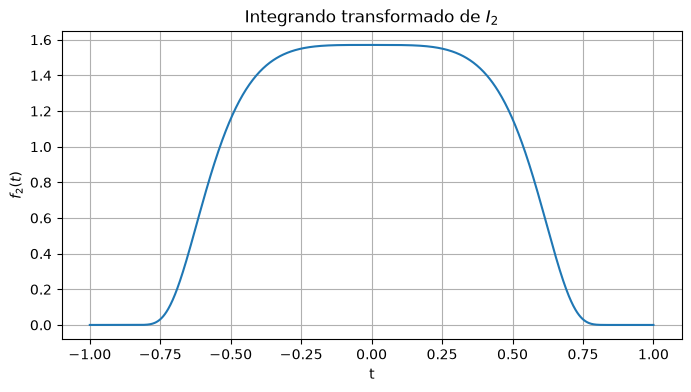

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(t2, f2_transformada(t2))
plt.xlabel('t')
plt.ylabel(r'$f_2(t)$')
plt.title('Integrando transformado de $I_2$')
plt.grid(True)
plt.show()

### 3. Métodos de integración numérica (15 puntos)

Utilice las implementaciones de trapecio compuesto y Simpson compuesto
desarrolladas en el trabajo anterior.

Para la cuadratura de Gaussiana, recuerde que los nodos y pesos
proporcionados por `roots_legendre(n)` corresponden al intervalo

$$
[-1,1].
$$

Para integrar en un intervalo general $[a,b]$, transforme los nodos mediante

$$
x_i=
\frac{b-a}{2}\xi_i+\frac{a+b}{2}
$$

y los pesos mediante

$$
w_i=
\frac{b-a}{2}\omega_i.
$$

In [10]:
def trapecio_compuesto(func, a, b, n):        
    '''
    TODO:
    Implemente aquí la regla del trapecio compuesto.

    Sugerencia:
    1. Calcule el ancho h de cada subintervalo.
    2. Construya los n+1 nodos.
    3. Evalúe f(x) en los nodos.
    4. Aplique la expresión del trapecio compuesto.
    '''
    h=(b-a)/n
    x_nodos=np.linspace(a,b, n+1)
    y= func(x_nodos)
    
    ITC= h*((y[0] + y[-1])/2 + (np.sum(y[1:-1:1])))
            # de 0 a el ultimo que es expresado como -1
            # ya que el final es exclusivo     
            
    return ITC
    

In [11]:
def simpson_compuesto(func, a, b, n):
    '''
    TODO:
    Implemente aquí la regla de Simpson compuesta.

    Sugerencia:
    1. Calcule h.
    2. Construya los n+1 nodos.
    3. Evalúe f(x) en los nodos.
    4. Sume por separado los términos con índices
       impares y pares.
    5. Aplique la expresión de Simpson compuesto.
    '''
    if n%2 !=0:
        raise ValueError
        
    h= (b-a)/n
    x_nodos= np.linspace(a,b, n+1)
    y=func(x_nodos)
                  
    sum_impar=np.sum(y[1:-1:2])
    sum_par= np.sum(y[2:-2:2])
                    #inicio:final:salto 2 en 2
    ISC= h/3 * (y[0]+ y[-1] + 4*sum_impar + 2*sum_par)
                    
    return ISC
    
    

In [12]:
def gauss_quad(func, a, b, n):

    # Nodos y pesos en [-1, 1]
    xi, wi = roots_legendre(n)

    '''
    TODO:
    Transforme los nodos xi y los pesos wi
    del intervalo [-1,1] al intervalo [a,b].
    '''

    x = 0.5 * (b - a) * xi + 0.5 * (b + a)
    w = 0.5 * (b - a) * wi


    '''
    TODO:
    Calcule y retorne la aproximación de la integral.
    '''
    
    IGQ= np.sum(w*func(x))
    
    return IGQ

### 4. Evaluación numérica (20 puntos)

Utilice

$$
n\in\{4,8,16,32,64\}.
$$

Para cada valor de $n$, aproxime ambas integrales mediante:

1. trapecio compuesto,
2. Simpson compuesto,
3. cuadratura de Gaussiana.

Utilice los intervalos transformados completos:

$$
0\leq t\leq1
$$

para $I_1$, y

$$
-1\leq t\leq1
$$

para $I_2$.

Almacene las aproximaciones obtenidas para utilizarlas posteriormente en el
análisis del error.

In [13]:
n_values = [4, 8, 16, 32, 64]

# Resultados para I1
I1_trapecio = []
I1_simpson = []
I1_gauss = []

# Resultados para I2
I2_trapecio = []
I2_simpson = []
I2_gauss = []

for n in n_values:

    # Integral I1
    I1_T = trapecio_compuesto(f1_transformada, 0, 1, n)
    I1_S = simpson_compuesto(f1_transformada, 0, 1, n)
    I1_G = gauss_quad(f1_transformada, 0, 1, n)

    # Integral I2
    I2_T = trapecio_compuesto(f2_transformada, -1, 1, n)
    I2_S = simpson_compuesto(f2_transformada, -1, 1, n)
    I2_G = gauss_quad(f2_transformada, -1, 1, n)

    '''
    TODO:
    Reemplace None por las llamadas correspondientes
    a los métodos de integración.
    '''

    I1_trapecio.append(I1_T)
    I1_simpson.append(I1_S)
    I1_gauss.append(I1_G)

    I2_trapecio.append(I2_T)
    I2_simpson.append(I2_S)
    I2_gauss.append(I2_G)

### 5. Análisis del error y convergencia (20 puntos)

Para cada aproximación calcule el error absoluto real

$$
E=
|I_{\mathrm{num}}-I_{\mathrm{exacta}}|.
$$

Para las dos integrales:

$$
I_{1,\mathrm{exacta}}=1
$$

y

$$
I_{2,\mathrm{exacta}}=\sqrt{\pi}.
$$

Calcule los errores correspondientes a cada método y grafique posteriormente

$$
E
$$

en función de $n$ utilizando escalas logarítmicas en ambos ejes.

In [14]:
I1_exacta = 1.0
I2_exacta = np.sqrt(np.pi)

# Conversión a arreglos para facilitar operaciones
I1_trapecio = np.array(I1_trapecio)
I1_simpson = np.array(I1_simpson)
I1_gauss = np.array(I1_gauss)

I2_trapecio = np.array(I2_trapecio)
I2_simpson = np.array(I2_simpson)
I2_gauss = np.array(I2_gauss)

'''
TODO:
Calcule los errores absolutos para cada método.
'''

error_I1_T = np.abs(I1_exacta-I1_trapecio)
error_I1_S = np.abs(I1_exacta-I1_simpson)
error_I1_G = np.abs(I1_exacta-I1_gauss)

error_I2_T = np.abs(I2_exacta-I2_trapecio)
error_I2_S = np.abs(I2_exacta-I2_simpson)
error_I2_G = np.abs(I2_exacta-I2_gauss)

In [15]:
print("Integral I1")
print("-" * 65)

for i, n in enumerate(n_values):
    print(
        f"n = {n:2d} | "
        f"Trapecio = {I1_trapecio[i]:.10f} | "
        f"Simpson = {I1_simpson[i]:.10f} | "
        f"Gauss = {I1_gauss[i]:.10f}"
    )

Integral I1
-----------------------------------------------------------------
n =  4 | Trapecio = 1.0104860749 | Simpson = 1.0187284724 | Gauss = 1.0234822407
n =  8 | Trapecio = 0.9975783271 | Simpson = 0.9932757446 | Gauss = 1.0007957926
n = 16 | Trapecio = 0.9996816202 | Simpson = 1.0003827179 | Gauss = 0.9999956133
n = 32 | Trapecio = 0.9999186673 | Simpson = 0.9999976830 | Gauss = 1.0000000006
n = 64 | Trapecio = 0.9999796548 | Simpson = 0.9999999840 | Gauss = 1.0000000000


In [16]:
print("Integral I2")
print("-" * 65)

for i, n in enumerate(n_values):
    print(
        f"n = {n:2d} | "
        f"Trapecio = {I2_trapecio[i]:.10f} | "
        f"Simpson = {I2_simpson[i]:.10f} | "
        f"Gauss = {I2_gauss[i]:.10f}"
    )

Integral I2
-----------------------------------------------------------------
n =  4 | Trapecio = 1.9411255132 | Simpson = 2.0645685753 | Gauss = 1.9492076910
n =  8 | Trapecio = 1.7614236853 | Simpson = 1.7015230760 | Gauss = 1.7982653295
n = 16 | Trapecio = 1.7720514107 | Simpson = 1.7755939859 | Gauss = 1.7726581320
n = 32 | Trapecio = 1.7724548923 | Simpson = 1.7725893861 | Gauss = 1.7724544403
n = 64 | Trapecio = 1.7724538507 | Simpson = 1.7724535035 | Gauss = 1.7724538509


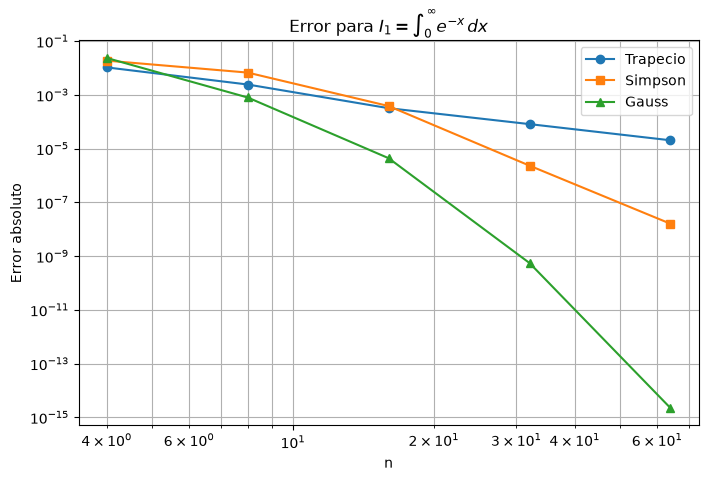

In [17]:
plt.figure(figsize=(8, 5))

plt.loglog(n_values, error_I1_T, 'o-', label='Trapecio')
plt.loglog(n_values, error_I1_S, 's-', label='Simpson')
plt.loglog(n_values, error_I1_G, '^-', label='Gauss')

plt.xlabel('n')
plt.ylabel('Error absoluto')
plt.title(r'Error para $I_1=\int_0^\infty e^{-x}\,dx$')
plt.grid(True, which='both')
plt.legend()

plt.show()

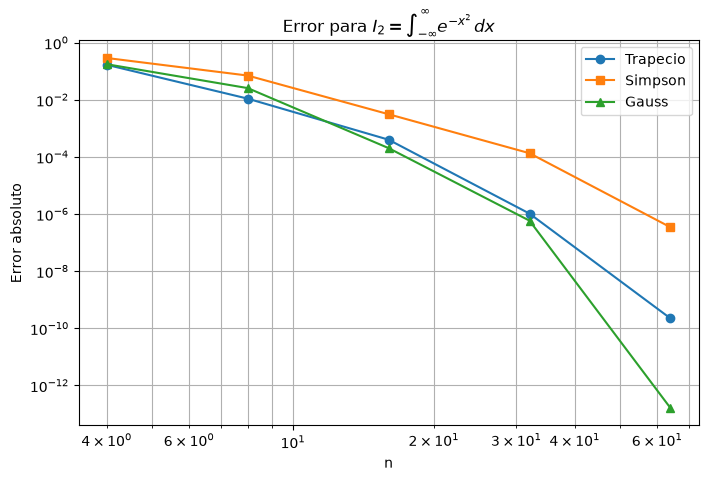

In [18]:
plt.figure(figsize=(8, 5))

plt.loglog(n_values, error_I2_T, 'o-', label='Trapecio')
plt.loglog(n_values, error_I2_S, 's-', label='Simpson')
plt.loglog(n_values, error_I2_G, '^-', label='Gauss')

plt.xlabel('n')
plt.ylabel('Error absoluto')
plt.title(r'Error para $I_2=\int_{-\infty}^{\infty}e^{-x^2}\,dx$')
plt.grid(True, which='both')
plt.legend()

plt.show()

### 6. Discusión (15 puntos)

Responda brevemente utilizando las expresiones transformadas y los resultados
numéricos obtenidos.

1. ¿Cuál de los tres métodos presenta la disminución más rápida del error
   para $I_1$?

2. ¿Cuál presenta la disminución más rápida del error para $I_2$?

3. ¿Los tres métodos se comportan de la misma manera para ambas integrales?
   Describa las diferencias que observa en las gráficas.

### Respuestas

1. cuadratura gaussiana 


2. seria el metodo de cuadratura gaussiana, justo en los dos primeros valores de n, sucede que el metodo del trapecio tiene una aproximacion mas certera, pero tener menor error para un valor pequeño de n no es lo mismo que converger más rápido


3. No, los tres métodos no se comportan igual para ambas integrales, trapecio converge más lento, simpson más rápido y la cuadratura gaussiana suele lograr menor error con pocos puntos, la diferencia depende de qué tan suave o difícil sea la función integrada.